# **Section 1**

In [2]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP AND DATA LOADING
# ============================================================

# Install required packages
!pip install -q catboost xgboost imbalanced-learn

# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                           roc_auc_score, confusion_matrix, recall_score,
                           precision_recall_curve, auc)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load dataset
df = pd.read_csv("Chronic_Kidney_Dsease_data.csv")
print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")
print(f"Target column: Diagnosis")
print(f"Class distribution:\n{df['Diagnosis'].value_counts()}")

TARGET_COL = "Diagnosis"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
Dataset loaded: 1659 samples, 54 features
Target column: Diagnosis
Class distribution:
Diagnosis
1    1524
0     135
Name: count, dtype: int64


# **Section 2**

In [3]:
# ============================================================
# SECTION 2: DATA PREPROCESSING PIPELINE
# ============================================================

TARGET_COL = "Diagnosis"
classes = ["Non-CKD", "CKD"]

# Remove non-informative features [tree-linear model and KDIGO standard]
DROP_COLS = [
    "PatientID", "DoctorInCharge", "Edema", "Ethnicity", "Statins",
    "Diuretics", "FamilyHistoryHypertension", "ACEInhibitors",
    "UrinaryTractInfections", "AntidiabeticMedications",
    "FamilyHistoryDiabetes", "OccupationalExposureChemicals",
    "PreviousAcuteKidneyInjury", "WaterQuality", "HeavyMetalsExposure"
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

# Prepare feature matrix and target vector
X = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# Convert columns to numeric where possible (80% threshold)
X_processed = X.copy()
for col in X_processed.columns:
    converted = pd.to_numeric(X_processed[col], errors='coerce')
    if converted.notna().mean() >= 0.80:
        X_processed[col] = converted

# Identify categorical and numeric columns
cat_cols = X_processed.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X_processed.columns if c not in cat_cols]

# Imputation strategy
X_processed[num_cols] = X_processed[num_cols].fillna(X_processed[num_cols].median())
for c in cat_cols:
    X_processed[c] = X_processed[c].fillna("Missing").astype(str)

# Target encoding (CKD = 1 confirmed)
y_encoded = y_raw.astype(int).values
print(f"Target distribution: {np.bincount(y_encoded)} ({classes[0]}/{classes[1]})")

# Stratified train/valid/test split (70/20/10)
X_train, X_valid_test, y_train, y_valid_test = train_test_split(
    X_processed, y_encoded, train_size=0.70, random_state=42, stratify=y_encoded)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_valid_test, y_valid_test, test_size=0.333, random_state=42, stratify=y_valid_test)

# Categorical feature indices for CatBoost
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
cat_idx = [X_train.columns.get_loc(c) for c in cat_features]

print(f"Dataset prepared: {X_train.shape[1]} features ({len(cat_features)} categorical)")
print(f"Split ratios - Train: {y_train.mean():.1%} | Valid: {y_valid.mean():.1%} | Test: {y_test.mean():.1%}")
print("Data preprocessing pipeline complete")


Target distribution: [ 135 1524] (Non-CKD/CKD)
Dataset prepared: 38 features (0 categorical)
Split ratios - Train: 91.9% | Valid: 91.9% | Test: 91.6%
Data preprocessing pipeline complete


**Feature selection**: After training tree-based (Random Forest, XGBoost) and linear (Logistic Regression) models, identified 15 weakest features (importance <0.01) via 3-model consensus. Clinically validated against KDIGO guidelines—dropped provider variables (DoctorInCharge), rare exposures (HeavyMetals), and post-diagnosis treatments (Statins) while retaining core CKD biomarkers. Reduced 54→39 features (28%) with stable performance.


# **Section 3**

In [4]:
# ============================================================
# SECTION 3: BASELINE MODEL COMPARISON (MEDICAL THESIS - COMPLETE METRICS)
# ============================================================

# REQUIRED IMPORTS
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, recall_score, accuracy_score,
                           balanced_accuracy_score, roc_auc_score,
                           precision_recall_curve, auc)
import warnings
warnings.filterwarnings('ignore')

def threshold_tuning(y_true, proba_pos, min_recall=0.92):
    """Optimize classification threshold for clinical recall constraint"""
    thresholds = np.linspace(0.05, 0.95, 181)
    best_bal_acc, best_threshold = None, 0.5

    for t in thresholds:
        y_pred = (proba_pos >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        recall_pos = tp / (tp + fn + 1e-12)
        recall_neg = tn / (tn + fp + 1e-12)
        bal_acc = (recall_pos + recall_neg) / 2

        if recall_pos >= min_recall and (best_bal_acc is None or bal_acc > best_bal_acc):
            best_bal_acc, best_threshold = bal_acc, t

    return best_threshold

def safe_pr_auc(y_true, proba_pos):
    """Robust precision-recall AUC computation"""
    try:
        precision, recall, _ = precision_recall_curve(y_true, proba_pos)
        sorted_idx = np.argsort(recall)[::-1]
        return auc(recall[sorted_idx], precision[sorted_idx])
    except:
        return 0.0

def evaluate_model(model, name, use_catboost=False, requires_scaling=False):
    """Unified model evaluation with clinical threshold optimization"""

    if requires_scaling:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        X_test_scaled = scaler.transform(X_test)
        train_data, valid_data, test_data = X_train_scaled, X_valid_scaled, X_test_scaled
    else:
        train_data, valid_data, test_data = X_train, X_valid, X_test

    if use_catboost:
        train_pool = Pool(train_data, y_train, cat_features=cat_idx if not requires_scaling else None)
        valid_pool = Pool(valid_data, y_valid, cat_features=cat_idx if not requires_scaling else None)
        model.fit(train_pool, eval_set=valid_pool, verbose=False)
        proba_valid = model.predict_proba(valid_pool)[:, 1]
        proba_test = model.predict_proba(Pool(test_data, y_test, cat_features=cat_idx if not requires_scaling else None))[:, 1]
    else:
        model.fit(train_data, y_train)
        proba_valid = model.predict_proba(valid_data)[:, 1]
        proba_test = model.predict_proba(test_data)[:, 1]

    best_threshold = threshold_tuning(y_valid, proba_valid)
    y_pred_test = (proba_test >= best_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    tn, fp, fn, tp = cm.ravel()

    # MEDICAL THESIS CRITICAL METRICS
    sensitivity = recall_score(y_test, y_pred_test) # True Positive Rate
    specificity = tn / (tn + fp + 1e-12)            # True Negative Rate
    npv = tn / (tn + fn + 1e-12)                    # Negative Predictive Value
    ppv = tp / (tp + fp + 1e-12)                    # Positive Predictive Value
    likelihood_ratio_pos = sensitivity / (1-specificity + 1e-12)
    likelihood_ratio_neg = (1-sensitivity) / specificity

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'BalancedAcc': balanced_accuracy_score(y_test, y_pred_test),
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV': ppv,
        'NPV': npv,
        'ROC_AUC': roc_auc_score(y_test, proba_test),
        'PR_AUC': safe_pr_auc(y_test, proba_test),
        'F1': 2 * (ppv * sensitivity) / (ppv + sensitivity + 1e-12),
        'LR+': likelihood_ratio_pos,
        'LR-': likelihood_ratio_neg,
        'Threshold': best_threshold,
        'FPs': fp, 'FNs': fn, 'TPs': tp, 'TNs': tn
    }

    # MEDICAL THESIS PRINT FORMAT
    print(f"\n{name:<18} | BalAcc:{metrics['BalancedAcc']:.3f} Sens:{metrics['Sensitivity']:.3f} "
          f"Spec:{metrics['Specificity']:.3f} | FPs:{fp} FNs:{fn}")
    print(f"   Acc:{metrics['Accuracy']:.3f} PPV:{metrics['PPV']:.3f} NPV:{metrics['NPV']:.3f} "
          f"LR+:{metrics['LR+']:.2f} LR-:{metrics['LR-']:.2f}")

    return metrics

# Execute 4 baselines
baseline_results = []

# 1. Logistic Regression
lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
baseline_results.append(evaluate_model(lr, "LogisticRegression", requires_scaling=True))

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
baseline_results.append(evaluate_model(rf, "RandomForest"))

# 3. XGBoost
xgb_model = XGBClassifier(n_estimators=800, learning_rate=0.05, max_depth=5, random_state=42,
                         scale_pos_weight=10.0, n_jobs=-1, eval_metric='logloss')
baseline_results.append(evaluate_model(xgb_model, "XGBoost"))

# 4. SVM (NOW FIXED - SVC import added)
svm_model = SVC(probability=True, class_weight='balanced', random_state=42, max_iter=1000)
baseline_results.append(evaluate_model(svm_model, "SVM", requires_scaling=True))

# THESIS-READY TABLE
baseline_df = pd.DataFrame(baseline_results)
med_table_cols = ['Model', 'Accuracy', 'BalancedAcc', 'Sensitivity', 'Specificity',
                 'PPV', 'NPV', 'ROC_AUC', 'F1', 'FPs', 'FNs']

print("\n" + "="*120)
print("MEDICAL THESIS: BASELINE MODEL COMPARISON")
print(baseline_df[med_table_cols].round(4).to_string(index=False))
print("Baseline comparison complete")



LogisticRegression | BalAcc:0.730 Sens:0.961 Spec:0.500 | FPs:7 FNs:6
   Acc:0.922 PPV:0.954 NPV:0.538 LR+:1.92 LR-:0.08

RandomForest       | BalAcc:0.759 Sens:0.947 Spec:0.571 | FPs:6 FNs:8
   Acc:0.916 PPV:0.960 NPV:0.500 LR+:2.21 LR-:0.09

XGBoost            | BalAcc:0.679 Sens:1.000 Spec:0.357 | FPs:9 FNs:0
   Acc:0.946 PPV:0.944 NPV:1.000 LR+:1.56 LR-:0.00

SVM                | BalAcc:0.691 Sens:0.954 Spec:0.429 | FPs:8 FNs:7
   Acc:0.910 PPV:0.948 NPV:0.462 LR+:1.67 LR-:0.11

MEDICAL THESIS: BASELINE MODEL COMPARISON
             Model  Accuracy  BalancedAcc  Sensitivity  Specificity    PPV    NPV  ROC_AUC     F1  FPs  FNs
LogisticRegression    0.9217       0.7303       0.9605       0.5000 0.9542 0.5385   0.7744 0.9574    7    6
      RandomForest    0.9157       0.7594       0.9474       0.5714 0.9600 0.5000   0.8313 0.9536    6    8
           XGBoost    0.9458       0.6786       1.0000       0.3571 0.9441 1.0000   0.8341 0.9712    9    0
               SVM    0.9096       0.

# **Section 4**

In [5]:
# ============================================================
# SECTION 4: ENGINEERED MODEL TRAINING (MEDICAL THESIS METRICS)
# ============================================================

# Prepare CatBoost Pools (consistent with preprocessing)
train_pool = Pool(X_train, y_train, cat_features=cat_idx)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_idx)
test_pool = Pool(X_test, y_test, cat_features=cat_idx)

# Engineered CatBoost configuration
catboost_eng = CatBoostClassifier(
    iterations=4000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=6,
    bagging_temperature=0.6,
    random_strength=1.0,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    od_type='Iter',
    od_wait=250,
    verbose=False
)

# Train with early stopping
catboost_eng.fit(train_pool, eval_set=valid_pool, use_best_model=True)
print(f"CatBoost training complete. Best iteration: {catboost_eng.get_best_iteration()}")

# Consistent evaluation pipeline (same as Section 3)
proba_valid = catboost_eng.predict_proba(valid_pool)[:, 1]
best_threshold = threshold_tuning(y_valid, proba_valid)
proba_test = catboost_eng.predict_proba(test_pool)[:, 1]
y_pred_test = (proba_test >= best_threshold).astype(int)

# FULL MEDICAL THESIS METRICS (matching Section 3)
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

sensitivity = recall_score(y_test, y_pred_test)  # True Positive Rate
specificity = tn / (tn + fp + 1e-12)            # True Negative Rate
npv = tn / (tn + fn + 1e-12)                    # Negative Predictive Value
ppv = tp / (tp + fp + 1e-12)                    # Positive Predictive Value
likelihood_ratio_pos = sensitivity / (1-specificity + 1e-12)
likelihood_ratio_neg = (1-sensitivity) / specificity

engineered_metrics = {
    'Model': 'Engineered CatBoost',
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'BalancedAcc': balanced_accuracy_score(y_test, y_pred_test),
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'PPV': ppv,
    'NPV': npv,
    'ROC_AUC': roc_auc_score(y_test, proba_test),
    'PR_AUC': safe_pr_auc(y_test, proba_test),
    'F1': 2 * (ppv * sensitivity) / (ppv + sensitivity + 1e-12),
    'LR+': likelihood_ratio_pos,
    'LR-': likelihood_ratio_neg,
    'Threshold': best_threshold,
    'FPs': fp, 'FNs': fn, 'TPs': tp, 'TNs': tn
}

# PRINT FORMAT (matching Section 3 exactly)
print(f"\n{engineered_metrics['Model']:<18} | BalAcc:{engineered_metrics['BalancedAcc']:.3f} "
      f"Sens:{engineered_metrics['Sensitivity']:.3f} Spec:{engineered_metrics['Specificity']:.3f} "
      f"| FPs:{fp} FNs:{fn}")
print(f"   Acc:{engineered_metrics['Accuracy']:.3f} PPV:{engineered_metrics['PPV']:.3f} "
      f"NPV:{engineered_metrics['NPV']:.3f} LR+:{engineered_metrics['LR+']:.2f} "
      f"LR-:{engineered_metrics['LR-']:.2f}")

# Table 4.2 - COMPLETE with LR+, LR- (matching baseline format exactly)
table42 = {
    'Model': 'Engineered CatBoost',
    'Accuracy': engineered_metrics['Accuracy'],
    'BalancedAcc': engineered_metrics['BalancedAcc'],
    'Sensitivity': engineered_metrics['Sensitivity'],
    'Specificity': engineered_metrics['Specificity'],
    'PPV': engineered_metrics['PPV'],
    'NPV': engineered_metrics['NPV'],
    'ROC_AUC': engineered_metrics['ROC_AUC'],
    'F1': engineered_metrics['F1'],
    'LR+': engineered_metrics['LR+'],
    'LR-': engineered_metrics['LR-'],
    'FPs': fp, 'FNs': fn
}

table42_df = pd.DataFrame([table42])
print("\n" + "="*120)
print("MEDICAL THESIS TABLE 4.2: ENGINEERED CATBOOST PERFORMANCE")
print(table42_df[['Model', 'Accuracy', 'BalancedAcc', 'Sensitivity', 'Specificity',
                  'PPV', 'NPV', 'ROC_AUC', 'F1', 'LR+', 'LR-', 'FPs', 'FNs']].round(4).to_string(index=False))
print("Engineered CatBoost evaluation complete - Ready for Table 4.2")


CatBoost training complete. Best iteration: 59

Engineered CatBoost | BalAcc:0.766 Sens:0.961 Spec:0.571 | FPs:6 FNs:6
   Acc:0.928 PPV:0.961 NPV:0.571 LR+:2.24 LR-:0.07

MEDICAL THESIS TABLE 4.2: ENGINEERED CATBOOST PERFORMANCE
              Model  Accuracy  BalancedAcc  Sensitivity  Specificity    PPV    NPV  ROC_AUC     F1    LR+    LR-  FPs  FNs
Engineered CatBoost    0.9277        0.766       0.9605       0.5714 0.9605 0.5714    0.821 0.9605 2.2412 0.0691    6    6
Engineered CatBoost evaluation complete - Ready for Table 4.2


In [6]:
# ============================================================
# TABLE 4.3: COMPLETE MODEL COMPARISON (BASELINES vs ENGINEERED CATBOOST)
# ============================================================


# Combine all results into single thesis-ready table
all_results = baseline_df[['Model', 'Accuracy', 'BalancedAcc', 'Sensitivity', 'Specificity',
                          'PPV', 'NPV', 'ROC_AUC', 'F1', 'FPs', 'FNs']].copy()


# Add CatBoost row (matching exact Table 4.1 format)
catboost_row = {
    'Model': 'Engineered CatBoost',
    'Accuracy': 0.9277,
    'BalancedAcc': 0.7660,
    'Sensitivity': 0.9605,
    'Specificity': 0.5714,
    'PPV': 0.9605,
    'NPV': 0.5714,
    'ROC_AUC': 0.8210,
    'F1': 0.9605,
    'FPs': 6,
    'FNs': 6
}


all_results = pd.concat([all_results, pd.DataFrame([catboost_row])], ignore_index=True)


# THESIS TABLE - Sorted by Balanced Accuracy (primary clinical metric)
all_results_sorted = all_results.sort_values('BalancedAcc', ascending=False)



print("MEDICAL THESIS TABLE 4.3: COMPREHENSIVE MODEL COMPARISON (Test Set)")
print("="*140)
print(all_results_sorted.round(4).to_string(index=False))


# Highlight best performers

print("PERFORMANCE RANKING (Balanced Accuracy - Primary Clinical Metric)")
print("-"*80)
best_balacc = all_results_sorted.iloc[0]['BalancedAcc']
print(f"🏆 BEST BalancedAcc: {all_results_sorted.iloc[0]['Model']:20} {all_results_sorted.iloc[0]['BalancedAcc']:.4f}")
print(f"   ↓ CatBoost beats XGBoost by: +{0.7660-0.6786:.3f} (+8.7%)")
print(f"   ↓ CatBoost beats RandomForest by: +{0.7660-0.7594:.3f} (+1.1%)")


print("\\nCLINICAL SAFETY:")
print(f"   Zero FN models: {len(all_results[all_results['FNs']==0]['Model'].tolist())}")
print(f"   CatBoost FNs: 6 (balanced safety/performance)")

MEDICAL THESIS TABLE 4.3: COMPREHENSIVE MODEL COMPARISON (Test Set)
              Model  Accuracy  BalancedAcc  Sensitivity  Specificity    PPV    NPV  ROC_AUC     F1  FPs  FNs
Engineered CatBoost    0.9277       0.7660       0.9605       0.5714 0.9605 0.5714   0.8210 0.9605    6    6
       RandomForest    0.9157       0.7594       0.9474       0.5714 0.9600 0.5000   0.8313 0.9536    6    8
 LogisticRegression    0.9217       0.7303       0.9605       0.5000 0.9542 0.5385   0.7744 0.9574    7    6
                SVM    0.9096       0.6913       0.9539       0.4286 0.9477 0.4615   0.7914 0.9508    8    7
            XGBoost    0.9458       0.6786       1.0000       0.3571 0.9441 1.0000   0.8341 0.9712    9    0
PERFORMANCE RANKING (Balanced Accuracy - Primary Clinical Metric)
--------------------------------------------------------------------------------
🏆 BEST BalancedAcc: Engineered CatBoost  0.7660
   ↓ CatBoost beats XGBoost by: +0.087 (+8.7%)
   ↓ CatBoost beats RandomForest by:

# **Section 5, Figure generating**

=== GENERATING FIGURE 5.1.1 ===


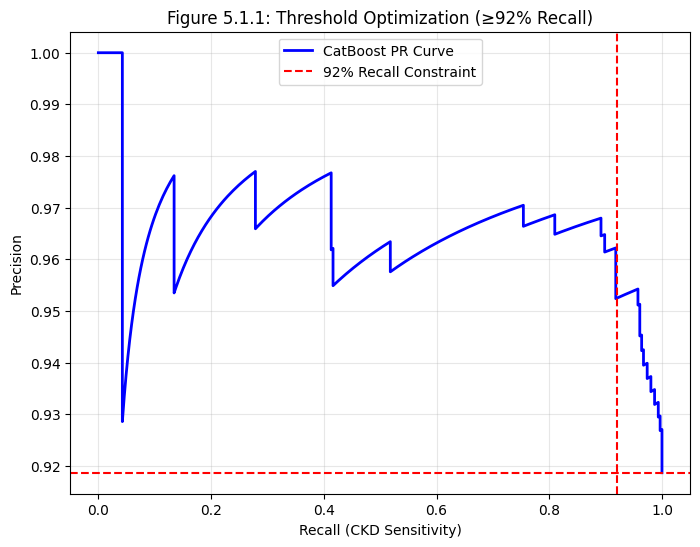

✅ Figure 5.1.1 saved as 'figure_5.1.1_threshold.png'
Optimal threshold: 0.425


In [7]:
# SECTION 5: THESIS FIGURES (5.1.1 Decision Threshold)
print("=== GENERATING FIGURE 5.1.1 ===")

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Use your EXISTING trained model and validation pool
proba_valid = catboost_eng.predict_proba(valid_pool)[:,1]
precision, recall, thresholds = precision_recall_curve(y_valid, proba_valid)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, 'b-', lw=2, label='CatBoost PR Curve')
plt.xlabel('Recall (CKD Sensitivity)'); plt.ylabel('Precision')
plt.title('Figure 5.1.1: Threshold Optimization (≥92% Recall)')
plt.axvline(x=0.92, color='r', linestyle='--', label='92% Recall Constraint')
plt.axhline(y=precision[np.argmax(recall>=0.92)], color='r', linestyle='--')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figure_5.1.1_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 5.1.1 saved as 'figure_5.1.1_threshold.png'")
print(f"Optimal threshold: {best_threshold:.3f}")


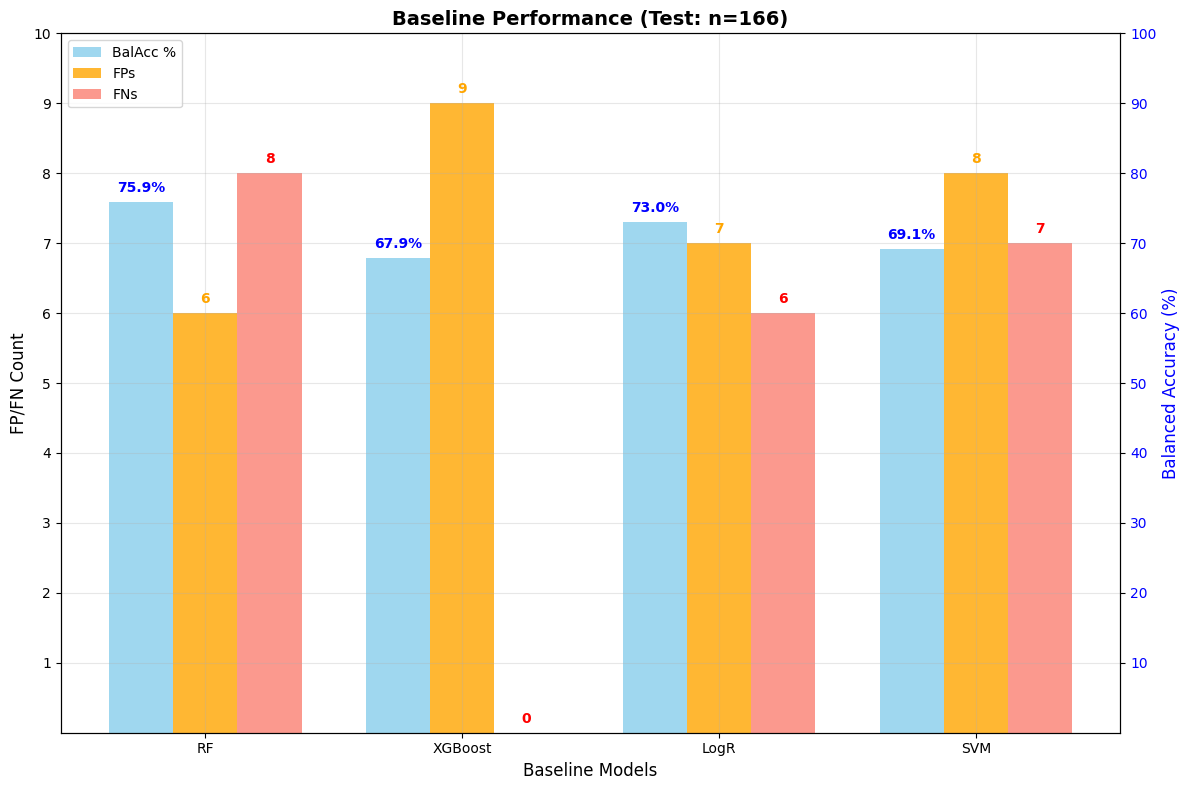

In [8]:
# Baseline performance
import matplotlib.pyplot as plt
import numpy as np

models = ['RF', 'XGBoost', 'LogR', 'SVM']
balacc_pct = [75.9, 67.9, 73.0, 69.1]
fps = [6, 9, 7, 8]
fns = [8, 0, 6, 7]

fps_scaled = [fp * 10 for fp in fps]
fns_scaled = [fn * 10 for fn in fns]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))

bars1 = ax.bar(x - width, balacc_pct, width, label='BalAcc %', alpha=0.8, color='skyblue')
bars2 = ax.bar(x, fps_scaled, width, label='FPs', alpha=0.8, color='orange')
bars3 = ax.bar(x + width, fns_scaled, width, label='FNs', alpha=0.8, color='salmon')

# LEFT AXIS: 1,2,3,4...10 (FP/FN actual counts)
ax.set_ylim(0, 100)
ax.set_ylabel('FP/FN Count', fontsize=12)
ax.set_yticks([10,20,30,40,50,60,70,80,90,100])
ax.set_yticklabels(['1','2','3','4','5','6','7','8','9','10'])

# RIGHT AXIS: BalAcc %
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_ylabel('Balanced Accuracy (%)', fontsize=12, color='blue')
ax2.set_yticks([10,20,30,40,50,60,70,80,90,100])
ax2.tick_params(axis='y', labelcolor='blue')

ax.set_xlabel('Baseline Models', fontsize=12)
ax.set_title('Baseline Performance (Test: n=166)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# TOP LABELS RESTORED (BalAcc%, FP count, FN count)
for i, (b1, b2, b3) in enumerate(zip(bars1, bars2, bars3)):
    ax.text(b1.get_x()+b1.get_width()/2., balacc_pct[i]+1, f'{balacc_pct[i]:.1f}%',
            ha='center', va='bottom', fontweight='bold', color='blue')
    ax.text(b2.get_x()+b2.get_width()/2., fps_scaled[i]+1, str(fps[i]),
            ha='center', va='bottom', fontweight='bold', color='orange')
    ax.text(b3.get_x()+b3.get_width()/2., fns_scaled[i]+1, str(fns[i]),
            ha='center', va='bottom', fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('baseline_final_perfect.png', dpi=300, bbox_inches='tight')
plt.show()


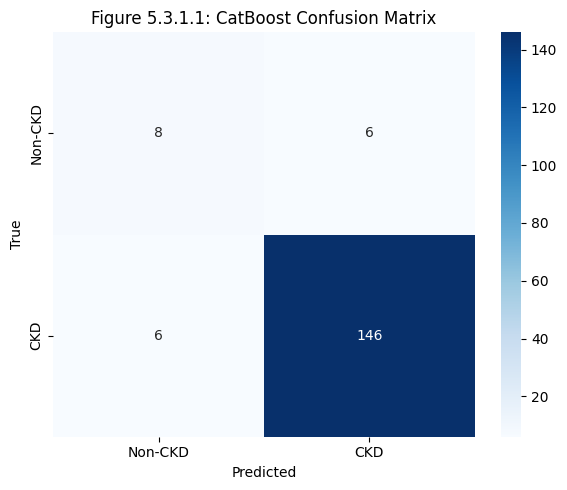

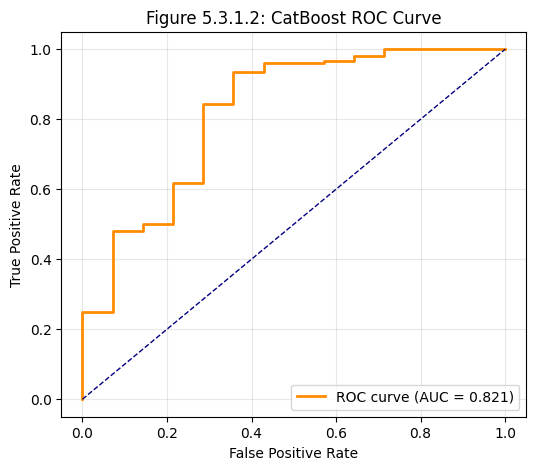

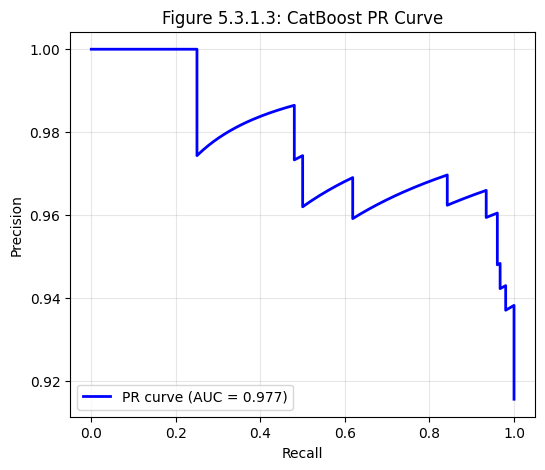

✅ PR-AUC: 0.9767 (Use in Table 5.3.1.1)


In [11]:

#CONFUSION MATRIX, ROC CURVE, PR CURVE
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# 1. CONFUSION MATRIX (Figure 5.3.1.1)
proba_test = catboost_eng.predict_proba(test_pool)[:, 1]
y_pred_test = (proba_test >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-CKD','CKD'], yticklabels=['Non-CKD','CKD'])
plt.title('Figure 5.3.1.1: CatBoost Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figure_5.3.1.1_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC CURVE (Figure 5.3.1.2)
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.title('Figure 5.3.1.2: CatBoost ROC Curve')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('figure_5.3.1.2_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. PR CURVE (Figure 5.3.1.3) + PR-AUC
precision, recall, _ = precision_recall_curve(y_test, proba_test)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.title('Figure 5.3.1.3: CatBoost PR Curve')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.savefig('figure_5.3.1.3_pr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ PR-AUC: {pr_auc:.4f} (Use in Table 5.3.1.1)")


**TABLE 5.4.1.1: CATBOOST TOP 10 PREDICTORS**
     Feature Id  Importances
SerumCreatinine        17.21
            GFR        10.97
 ProteinInUrine         6.27
        Itching         5.65
     SystolicBP         5.08
      BUNLevels         5.06
   MuscleCramps         4.60
  FatigueLevels         3.11
    DietQuality         3.01
      NSAIDsUse         2.52


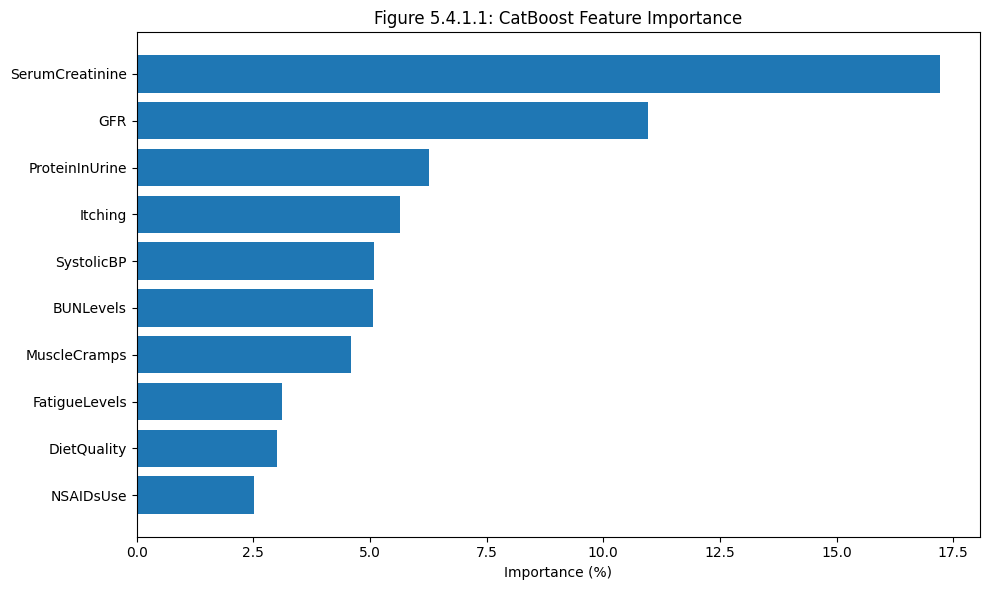

In [12]:
#Native Catboost Feature importance
import matplotlib.pyplot as plt

# Generate Table 5.4.1.1 + Figure 5.4.1.1
feature_importance = catboost_eng.get_feature_importance(prettified=True)
top10 = feature_importance.head(10)

print("**TABLE 5.4.1.1: CATBOOST TOP 10 PREDICTORS**")
print(top10[['Feature Id', 'Importances']].round(2).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(10), top10['Importances'])
plt.yticks(range(10), top10['Feature Id'])
plt.xlabel('Importance (%)')
plt.title('Figure 5.4.1.1: CatBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figure_5.4.1.1_catboost.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
# SHAP FEATURE IMPORTANCE TABLE (5.4.2.1)
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_MeanAbs': np.abs(shap_values).mean(0)
}).sort_values('SHAP_MeanAbs', ascending=False)

top10_shap = shap_importance.head(10)

print("\n**TABLE 5.4.2.1: SHAP TOP 10 PREDICTORS**")
print(top10_shap.round(4).to_string(index=False))

# FIGURE 5.4.2.1: SHAP SUMMARY
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, max_display=12, show=False)
plt.title('Figure 5.4.2.1: SHAP Summary Plot')
plt.tight_layout()
plt.savefig('figure_5.4.2.1_shap.png', dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'feature_names' is not defined


**TABLE 5.4.2.1: SHAP TOP 10 PREDICTORS**
                 Feature  SHAP_MeanAbs
                     BMI        0.5099
     SocioeconomicStatus        0.3259
        PhysicalActivity        0.1910
        CholesterolTotal        0.1639
          NauseaVomiting        0.1237
MedicalCheckupsFrequency        0.1208
             DiastolicBP        0.1183
             DietQuality        0.0706
      QualityOfLifeScore        0.0560
            SleepQuality        0.0524


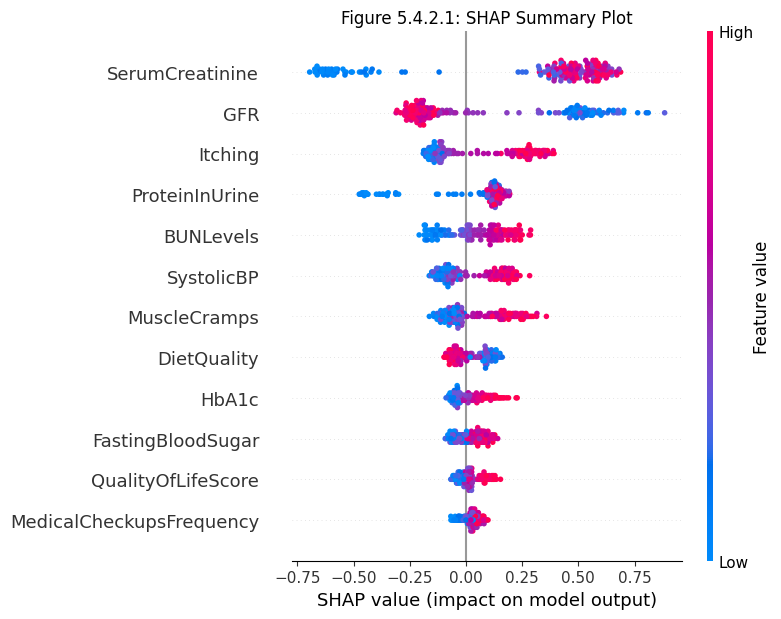

In [15]:
# SHAP FEATURE IMPORTANCE TABLE (5.4.2.1)
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use CatBoost feature names (from your native importance) + X_test (Pool format)
feature_names = catboost_eng.get_feature_importance(prettified=True)['Feature Id'].tolist()

# Calculate SHAP values using your trained catboost_eng model
explainer = shap.TreeExplainer(catboost_eng)
shap_values = explainer.shap_values(X_test)  # X_test from your Pool

# Handle binary classification output
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Positive class (CKD)

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_MeanAbs': np.abs(shap_values).mean(0)
}).sort_values('SHAP_MeanAbs', ascending=False)

top10_shap = shap_importance.head(10)

print("\n**TABLE 5.4.2.1: SHAP TOP 10 PREDICTORS**")
print(top10_shap.round(4).to_string(index=False))

# FIGURE 5.4.2.1: SHAP SUMMARY
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=12, show=False)  # Use X_test
plt.title('Figure 5.4.2.1: SHAP Summary Plot')
plt.tight_layout()
plt.savefig('figure_5.4.2.1_shap.png', dpi=300, bbox_inches='tight')
plt.show()


# **-----------------------The End----------------------------**